# Notebook Gabungan: TF-IDF (Paper) + Sentence-BERT

Notebook ini menggabungkan dua tahap dalam satu file agar bisa dijalankan sekaligus:
- **Bagian 1** — Pipeline dasar (TF-IDF + KNN/NB/SVM, sesuai notebook `TEST03_2_final`).
- **Bagian 2** — Eksperimen lanjutan Sentence-BERT (`TEST03_4_SBERT`).

Jalankan **Runtime → Run all** dari atas ke bawah. Pastikan GPU aktif (T4) untuk Bagian 2.

# KLASIFIKASI GENRE GAME BERDASARKAN SINOPSIS
---
**Author:** *Muhammad Wira Widhana [24.55.2717]*

> Alur penelitian mengikuti paper referensi (KNN):
> Pengumpulan Data -> Preprocessing -> Pembobotan TF-IDF -> Klasifikasi KNN -> Evaluasi (Confusion Matrix).
> Naive Bayes & SVM ditambahkan sebagai pembanding (sesuai bagian Saran paper).

In [21]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


## Library & Load Dataset

library

In [22]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import re
import ast
import math
import nltk
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
from nltk.stem import PorterStemmer

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_validate
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import LabelEncoder

from sklearn.naive_bayes import MultinomialNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import LinearSVC

from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    mean_squared_error,
)

from IPython.display import display

In [23]:
# pertama kali saja:

nltk.download('punkt')
nltk.download('punkt_tab')
nltk.download('stopwords')

# digunakan di preprocessing
english_stopwords = set(stopwords.words('english'))
stemmer = PorterStemmer()

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


## Load dan Memeriksa Data (Data Loading & EDA)

Load Dataset

In [24]:
import pandas as pd

# Load Dataset
df_raw = pd.read_csv('/content/drive/MyDrive/Thesis_s2/games_fixed.csv')

print("Ukuran awal dataset:", df_raw.shape)
df_raw.head()

Ukuran awal dataset: (122611, 36)


,AppID,Name,Release date,Estimated owners,Peak CCU,Required age,Price,Discount,DLC count,About the game,...,Median playtime two weeks,Average playtime forever,Median playtime forever,Developers,Publishers,Categories,Genres,Tags,Screenshots,Movies
0,10,Counter-Strike,"Nov 1, 2000",10000000 - 20000000,7323,0,1.99,80,0,Play the world's number 1 online action game. ...,...,99,10735,185,['Valve'],['Valve'],"['Multi-player', 'PvP', 'Online PvP', 'Shared/...",['Action'],"{'Action': 5504, 'FPS': 4929, 'Multiplayer': 3...",['https://shared.akamai.steamstatic.com/store_...,[]
1,100,Counter-Strike: Condition Zero,"Mar 1, 2004",10000000 - 20000000,83,0,1.99,80,0,"With its extensive Tour of Duty campaign, a ne...",...,1,431,32,['Valve'],['Valve'],"['Single-player', 'Multi-player', 'Color Alter...",['Action'],"{'Action': 1339, 'FPS': 979, 'Shooter': 723, '...",['https://shared.akamai.steamstatic.com/store_...,[]
2,1000000,ASCENXION,"May 14, 2021",0 - 20000,0,0,1.49,0,1,ASCENXION is a 2D shoot 'em up game where you ...,...,0,0,0,['IndigoBlue Game Studio'],['PsychoFlux Entertainment'],"['Single-player', 'Steam Achievements', 'Parti...","['Action', 'Adventure', 'Indie']","{""Shoot 'Em Up"": 186, 'Metroidvania': 181, 'Bu...",['https://shared.akamai.steamstatic.com/store_...,[]
3,1000010,Crown Trick,"Oct 16, 2020",500000 - 1000000,14,0,4.99,0,2,Crown Trick is a beautifully animated rogue-li...,...,0,702,397,['NEXT Studios'],"['Team17', 'NEXT Studios']","['Single-player', 'Steam Achievements', 'Steam...","['Adventure', 'Indie', 'RPG', 'Strategy']","{'Rogue-like': 275, 'Turn-Based Combat': 258, ...",['https://shared.akamai.steamstatic.com/store_...,[]
4,1000030,"Cook, Serve, Delicious! 3?!","Oct 14, 2020",100000 - 200000,27,0,4.99,75,1,Hit the road in this massive sequel to the mil...,...,0,281,118,['Vertigo Gaming Inc.'],['Vertigo Gaming Inc.'],"['Single-player', 'Multi-player', 'Co-op', 'Sh...","['Action', 'Indie', 'Simulation', 'Strategy']","{'Typing': 227, 'Management': 219, 'Difficult'...",['https://shared.akamai.steamstatic.com/store_...,[]


>Penjelasan singkat: Membaca dataset `games_fixed.csv` yang merupakan dataset dari kaggle

Seleksi kolom yang dibutuhkan (judul, sinopsis, genre)

In [25]:
# Seleksi kolom: judul, sinopsis, genre
df = df_raw[['Name', 'About the game', 'Genres']].copy()

df.rename(columns={
    'Name': 'title',
    'About the game': 'synopsis',
    'Genres': 'genre_raw'
}, inplace=True)

print("Jumlah data setelah seleksi kolom:", df.shape)
df.sample(5)

Jumlah data setelah seleksi kolom: (122611, 3)


,title,synopsis,genre_raw
7356,Battle Map Studio,Battle Map Studio is a playful map editor and ...,"['Casual', 'Indie', 'RPG', 'Simulation', 'Earl..."
31743,IRON GUARD: Salvation,Join the fight for humanity’s survival in IRON...,"['Action', 'Strategy']"
22851,Alien Planet Explorer,"You play as a young explorer of alien planets,...","['Adventure', 'Indie']"
69009,Fluffquake Fury,Join Pippa Pillowfeather in her bid to escape ...,"['Action', 'Adventure', 'Indie', 'RPG', 'Free ..."
50488,Hidden Kitten,"Hey there, my human friend! I’m Charlie the ca...","['Casual', 'Indie']"


Cek missing values

In [26]:
# Cek missing values
df.isna().sum()

,0
title,1
synopsis,8448
genre_raw,0


Hapus baris yang tidak punya sinopsis atau genre

In [27]:
# Hapus baris yang tidak punya sinopsis atau genre
df = df.dropna(subset=['synopsis', 'genre_raw']).reset_index(drop=True)

# Tambahan: hapus genre yang kosong secara konten, seperti [], [''], dll.
df['genre_raw'] = df['genre_raw'].astype(str).str.strip()

# Filter keluar string yang merepresentasikan list kosong
df = df[~df['genre_raw'].isin(['[]', "['']", '[""]', '', 'nan'])].reset_index(drop=True)

print("Jumlah data setelah drop NA dan genre kosong:", df.shape)

Jumlah data setelah drop NA dan genre kosong: (114022, 3)


## Normalisasi Genre

Mengikuti paper: 4 genre dan single-label (satu data = satu genre).
Di sini dipakai 4 genre gameplay murni: **action, adventure, rpg, simulation**.

In [28]:
# Genre target: 4 genre gameplay murni (tanpa 'indie' & 'casual')
target_genres = {'action', 'adventure', 'rpg', 'simulation'}

def parse_genre_list(genre_str):
    '''
    Parse string genre seperti "['Action', 'Indie']" menjadi list python ['action', 'indie'].
    Parsing aman menggunakan ast.literal_eval (bukan replace manual).
    '''
    if pd.isna(genre_str):
        return []

    # Jika sudah list, kembalikan langsung
    if isinstance(genre_str, list):
        raw_list = genre_str
    else:
        text = str(genre_str).strip()
        try:
            # Coba parse sebagai literal Python
            raw_list = ast.literal_eval(text)
        except (ValueError, SyntaxError):
            # Cadangan: pisah manual dengan koma
            raw_list = [g.strip() for g in text.split(',')]

    # Normalisasi ke huruf kecil
    return [g.strip().lower() for g in raw_list if isinstance(g, str)]

# Terapkan parsing dan filter ke genre target
df['genre_list'] = df['genre_raw'].apply(parse_genre_list)
df['genre_filtered'] = df['genre_list'].apply(lambda lst: [g for g in lst if g in target_genres])
df['genre_count'] = df['genre_filtered'].apply(len)

df[['genre_raw', 'genre_list', 'genre_filtered', 'genre_count']].head()

,genre_raw,genre_list,genre_filtered,genre_count
0,['Action'],[action],[action],1
1,['Action'],[action],[action],1
2,"['Action', 'Adventure', 'Indie']","[action, adventure, indie]","[action, adventure]",2
3,"['Adventure', 'Indie', 'RPG', 'Strategy']","[adventure, indie, rpg, strategy]","[adventure, rpg]",2
4,"['Action', 'Indie', 'Simulation', 'Strategy']","[action, indie, simulation, strategy]","[action, simulation]",2


In [29]:
# Untuk menjaga single-label classification sesuai paper,
# hanya ambil data yang memiliki tepat satu genre target
df_single = df[df['genre_count'] == 1].copy().reset_index(drop=True)

# Ambil genre utama
df_single['genre_main'] = df_single['genre_filtered'].str[0]

print("Jumlah data setelah filter subset genre dan single-label:", df_single.shape)
df_single[['title', 'synopsis', 'genre_raw', 'genre_filtered', 'genre_main']].head(10)

Jumlah data setelah filter subset genre dan single-label: (51293, 7)


,title,synopsis,genre_raw,genre_filtered,genre_main
0,Counter-Strike,Play the world's number 1 online action game. ...,['Action'],[action],action
1,Counter-Strike: Condition Zero,"With its extensive Tour of Duty campaign, a ne...",['Action'],[action],action
2,Tower of Origin2-Worm's Nest,"If you want to talk to me , please follow this...","['Indie', 'RPG']",[rpg],rpg
3,Hellish Quart,Hellish Quart is a local-only (two players pla...,"['Action', 'Early Access']",[action],action
4,WRATH: Aeon of Ruin,You are Outlander. Once adrift upon the Ageles...,['Action'],[action],action
5,东方雪莲华 ～ Abyss Soul Lotus.,东方雪莲华 ～ Abyss Soul Lotus.是在东方Project世界观基础上创作的二...,"['Action', 'Indie']",[action],action
6,The Undisputables : Online Multiplayer Shooter,The Undisputables : Online Multiplayer is a co...,"['Action', 'Indie', 'Massively Multiplayer']",[action],action
7,Clam Man,Disclaimer! Clam Man is a game built around jo...,"['Adventure', 'Indie']",[adventure],adventure
8,Insomnis,The old Castevet manor has just been uninhabit...,"['Adventure', 'Indie']",[adventure],adventure
9,Flex Apocalypse Racing,An apocalypse has happened. Much has changed i...,"['Indie', 'Racing', 'Simulation', 'Sports']",[simulation],simulation


## Pembersihan Data

Buang sinopsis non-Inggris, placeholder, terlalu pendek, dan duplikat
agar data layak diklasifikasi (paper memakai sinopsis berbahasa Inggris).

In [30]:
# Filter sederhana: sinopsis dominan huruf Latin & tidak terlalu pendek
def basic_english_filter(text):
    if not isinstance(text, str):
        return False
    clean = re.sub(r'[^A-Za-z\s]', ' ', text)
    clean = re.sub(r'\s+', ' ', clean).strip()
    if len(clean.split()) < 3:
        return False
    return (len(clean) / max(len(text), 1)) >= 0.7

df_single['is_english'] = df_single['synopsis'].apply(basic_english_filter)
df_single = df_single[df_single['is_english']].drop(columns=['is_english']).reset_index(drop=True)
print("Jumlah data setelah filter bahasa Inggris:", df_single.shape)

Jumlah data setelah filter bahasa Inggris: (50378, 7)


In [31]:
# Buang sinopsis placeholder, terlalu pendek, dan duplikat
MIN_WORDS, MIN_CHARS = 10, 40
_syn = df_single['synopsis'].astype(str).str.strip()
word_count = _syn.str.split().apply(len)
char_count = _syn.str.len()

placeholder_re = re.compile(r'^(no description( available)?|coming soon|tba|tbd|n/?a|none|\.+|-+)$', re.I)
is_placeholder = _syn.apply(lambda s: bool(placeholder_re.match(s)))
too_short = (word_count < MIN_WORDS) | (char_count < MIN_CHARS)
is_dup = _syn.str.lower().duplicated(keep='first')

remove_mask = is_placeholder | too_short | is_dup
before = len(df_single)
df_single = df_single[~remove_mask].reset_index(drop=True)
print(f"Data sebelum: {before} -> sesudah: {len(df_single)} (dibuang {before - len(df_single)})")

Data sebelum: 50378 -> sesudah: 50262 (dibuang 116)


sebaran genre

In [32]:
df_single['genre_main'].value_counts()

,count
genre_main,
action,19862
adventure,14556
simulation,11278
rpg,4566


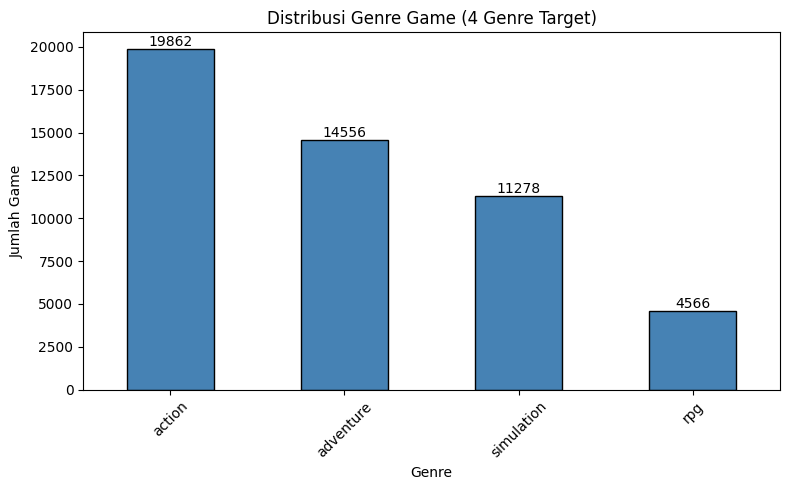

In [33]:
# Visualisasi distribusi genre (single-label, 4 genre target)
genre_counts = df_single['genre_main'].value_counts()

plt.figure(figsize=(8, 5))
ax = genre_counts.plot(kind='bar', color='steelblue', edgecolor='black')
plt.title('Distribusi Genre Game (4 Genre Target)')
plt.xlabel('Genre')
plt.ylabel('Jumlah Game')
plt.xticks(rotation=45)

for p in ax.patches:
    ax.annotate(
        f'{int(p.get_height())}',
        (p.get_x() + p.get_width() / 2., p.get_height()),
        ha='center', va='bottom', fontsize=10
    )

plt.tight_layout()
plt.show()

## Preprocessing

Urutan tahapan mengikuti paper:
`Case Folding -> Cleansing -> Stopword Removal -> Stemming -> Tokenization`

Disediakan 3 skenario untuk menguji kombinasi fitur preprocessing:
- **S1**: Case folding + Cleansing + Stopword removal + Tokenization
- **S2**: Case folding + Cleansing + Stemming + Tokenization
- **S3 (sesuai paper)**: Case folding + Cleansing + Stopword removal + Stemming + Tokenization

In [34]:
# 1) Case Folding: ubah semua huruf menjadi huruf kecil
def case_folding(text):
    return str(text).lower()

# 2) Cleansing: hapus URL, angka, tanda baca, dan karakter non-huruf
def cleansing(text):
    text = re.sub(r'http\S+', ' ', text)      # hapus URL
    text = re.sub(r'[^a-z\s]', ' ', text)      # hapus angka & tanda baca
    text = re.sub(r'\s+', ' ', text).strip()   # rapikan spasi berlebih
    return text

# 3) Stopword Removal: buang kata umum yang tidak informatif
def stopword_removal(text):
    return ' '.join(w for w in text.split() if w not in english_stopwords)

# 4) Stemming: kembalikan kata ke bentuk dasar (Porter Stemmer)
def stemming(text):
    return ' '.join(stemmer.stem(w) for w in text.split())

# 5) Tokenization: pisahkan teks menjadi token kata
def tokenization(text):
    return word_tokenize(text)

In [35]:
def preprocess(text, use_stopword=True, use_stemming=True):
    '''Pipeline preprocessing sesuai urutan paper.'''
    text = case_folding(text)            # 1. Case Folding
    text = cleansing(text)               # 2. Cleansing
    if use_stopword:
        text = stopword_removal(text)    # 3. Stopword Removal
    if use_stemming:
        text = stemming(text)            # 4. Stemming
    tokens = tokenization(text)          # 5. Tokenization
    return ' '.join(tokens)

In [36]:
# Terapkan ketiga skenario preprocessing
df_single['synopsis_S1'] = df_single['synopsis'].apply(lambda x: preprocess(x, True,  False))  # stopword only
df_single['synopsis_S2'] = df_single['synopsis'].apply(lambda x: preprocess(x, False, True))   # stemming only
df_single['synopsis_S3'] = df_single['synopsis'].apply(lambda x: preprocess(x, True,  True))   # SESUAI PAPER

df_single[['genre_main', 'synopsis', 'synopsis_S3']].head()

,genre_main,synopsis,synopsis_S3
0,action,Play the world's number 1 online action game. ...,play world number onlin action game engag incr...
1,action,"With its extensive Tour of Duty campaign, a ne...",extens tour duti campaign near limitless numbe...
2,rpg,"If you want to talk to me , please follow this...",want talk pleas follow twitter made frankli ma...
3,action,Hellish Quart is a local-only (two players pla...,hellish quart local two player play one pc onl...
4,action,You are Outlander. Once adrift upon the Ageles...,outland adrift upon ageless sea find shore die...


>Penjelasan singkat: Skenario S3 (stopword removal + stemming) adalah skenario utama sesuai paper.

## Pembobotan TF-IDF

Skenario utama = S3 (sesuai paper). Data dibagi 80% latih : 20% uji (stratified),
lalu TF-IDF di-`fit` hanya pada data latih.

In [37]:
# Skenario utama = S3 (sesuai paper)
TEXT_COL = 'synopsis_S3'
X_text = df_single[TEXT_COL]
y = df_single['genre_main']

# Split 80:20 stratified
X_train_text, X_test_text, y_train, y_test = train_test_split(
    X_text, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Jumlah data latih:", X_train_text.shape[0])
print("Jumlah data uji  :", X_test_text.shape[0])

Jumlah data latih: 40209
Jumlah data uji  : 10053


In [38]:
# Pembobotan TF-IDF (fit pada train, transform pada test)
tfidf = TfidfVectorizer(
    max_features=20000,
    ngram_range=(1, 2),
    sublinear_tf=True,
    min_df=3,
    max_df=0.95
)

X_train = tfidf.fit_transform(X_train_text)
X_test = tfidf.transform(X_test_text)

print("Dimensi matriks TF-IDF latih:", X_train.shape)
print("Dimensi matriks TF-IDF uji  :", X_test.shape)

Dimensi matriks TF-IDF latih: (40209, 20000)
Dimensi matriks TF-IDF uji  : (10053, 20000)


## Klasifikasi

Model utama **KNN** mengikuti paper (metric **euclidean**, **k = akar jumlah data latih**).
Naive Bayes & SVM ditambahkan sebagai pembanding.

In [39]:
# Nilai k mengikuti aturan paper: akar dari jumlah data latih
k = int(round(math.sqrt(X_train.shape[0])))
print("Nilai k (akar jumlah data latih):", k)

Nilai k (akar jumlah data latih): 201


In [40]:
# Model utama: K-Nearest Neighbors (sesuai paper)
knn = KNeighborsClassifier(n_neighbors=k, metric='euclidean')
knn.fit(X_train, y_train)
y_pred_knn = knn.predict(X_test)

In [41]:
# Pembanding 1: Naive Bayes
nb_clf = MultinomialNB(alpha=0.1)
nb_clf.fit(X_train, y_train)
y_pred_nb = nb_clf.predict(X_test)

In [42]:
# Pembanding 2: Support Vector Machine
svm_clf = LinearSVC(class_weight='balanced', max_iter=5000)
svm_clf.fit(X_train, y_train)
y_pred_svm = svm_clf.predict(X_test)

## Evaluasi (Confusion Matrix)

Evaluasi memakai: (a) Confusion Matrix, (b) **perhitungan manual TP/FP/FN/TN per kelas**
seperti tabel di paper, dan (c) ringkasan Accuracy, Precision, Recall, F1-Score.

In [43]:
def manual_confusion_matrix(y_true, y_pred, labels):
    '''
    Hitung TP, FP, FN, TN per kelas secara MANUAL dari confusion matrix,
    persis seperti contoh tabel pada paper referensi.
    - TP: prediksi benar untuk kelas tsb (diagonal)
    - FP: data kelas lain yang diprediksi sebagai kelas tsb (kolom - TP)
    - FN: data kelas tsb yang diprediksi sebagai kelas lain (baris - TP)
    - TN: sisanya
    '''
    cm = confusion_matrix(y_true, y_pred, labels=labels)
    total = cm.sum()
    rows = []
    for i, label in enumerate(labels):
        TP = int(cm[i, i])
        FP = int(cm[:, i].sum() - TP)
        FN = int(cm[i, :].sum() - TP)
        TN = int(total - TP - FP - FN)
        precision = TP / (TP + FP) if (TP + FP) > 0 else 0.0
        recall = TP / (TP + FN) if (TP + FN) > 0 else 0.0
        f1 = (2 * precision * recall / (precision + recall)) if (precision + recall) > 0 else 0.0
        rows.append({
            'Kelas': label,
            'TP': TP, 'FP': FP, 'FN': FN, 'TN': TN,
            'Precision': round(precision, 4),
            'Recall': round(recall, 4),
            'F1-Score': round(f1, 4),
        })
    return pd.DataFrame(rows)

In [44]:
def evaluate_model(y_true, y_pred, model_name):
    '''Tampilkan confusion matrix, tabel manual TP/FP/FN/TN, dan ringkasan metrik.'''
    labels = sorted(pd.Series(y_true).unique())
    cm = confusion_matrix(y_true, y_pred, labels=labels)

    print('=' * 60)
    print('MODEL:', model_name)
    print('=' * 60)

    # (a) Confusion matrix (heatmap)
    plt.figure(figsize=(6, 5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=labels, yticklabels=labels)
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.title(f'Confusion Matrix - {model_name}')
    plt.tight_layout()
    plt.show()

    # (b) Tabel manual TP/FP/FN/TN per kelas (seperti paper)
    print('Perhitungan Manual Confusion Matrix (per kelas):')
    tabel = manual_confusion_matrix(y_true, y_pred, labels)
    display(tabel)

    # (c) Ringkasan metrik keseluruhan (macro average)
    acc = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred, average='macro', zero_division=0)
    rec = recall_score(y_true, y_pred, average='macro', zero_division=0)
    f1 = f1_score(y_true, y_pred, average='macro', zero_division=0)
    print(f"Accuracy : {acc * 100:.2f}%")
    print(f"Precision: {prec * 100:.2f}%")
    print(f"Recall   : {rec * 100:.2f}%")
    print(f"F1-Score : {f1 * 100:.2f}%")

### Evaluasi KNN (model utama paper)

MODEL: K-Nearest Neighbors


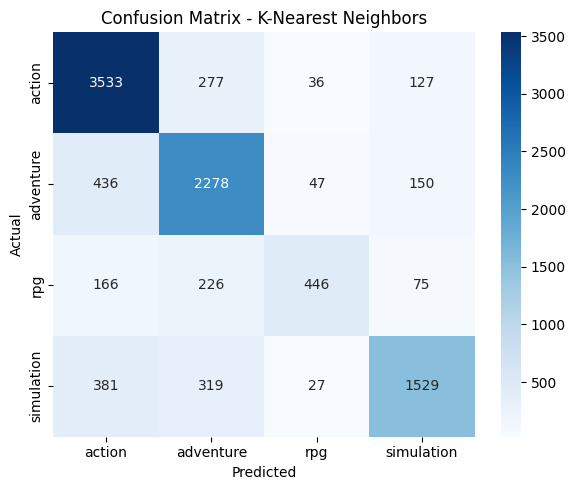

Perhitungan Manual Confusion Matrix (per kelas):


,Kelas,TP,FP,FN,TN,Precision,Recall,F1-Score
0,action,3533,983,440,5097,0.7823,0.8893,0.8324
1,adventure,2278,822,633,6320,0.7348,0.7825,0.7579
2,rpg,446,110,467,9030,0.8022,0.4885,0.6072
3,simulation,1529,352,727,7445,0.8129,0.6777,0.7392


Accuracy : 77.45%
Precision: 78.30%
Recall   : 70.95%
F1-Score : 73.42%


In [45]:
evaluate_model(y_test, y_pred_knn, 'K-Nearest Neighbors')

### Evaluasi Naive Bayes (pembanding)

MODEL: Naive Bayes


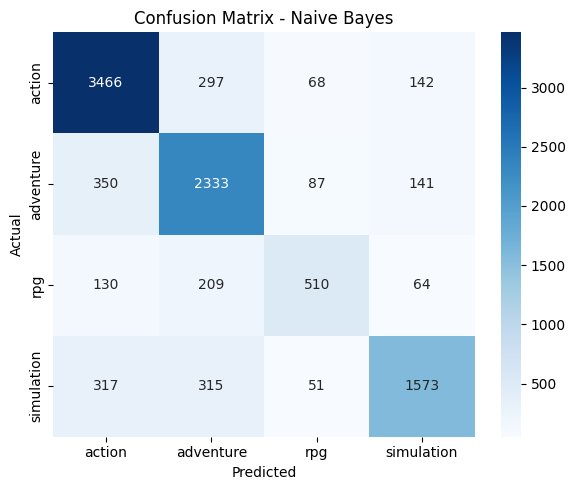

Perhitungan Manual Confusion Matrix (per kelas):


,Kelas,TP,FP,FN,TN,Precision,Recall,F1-Score
0,action,3466,797,507,5283,0.8130,0.8724,0.8417
1,adventure,2333,821,578,6321,0.7397,0.8014,0.7693
2,rpg,510,206,403,8934,0.7123,0.5586,0.6262
3,simulation,1573,347,683,7450,0.8193,0.6973,0.7534


Accuracy : 78.40%
Precision: 77.11%
Recall   : 73.24%
F1-Score : 74.76%


In [46]:
evaluate_model(y_test, y_pred_nb, 'Naive Bayes')

### Evaluasi SVM (pembanding)

MODEL: Support Vector Machine


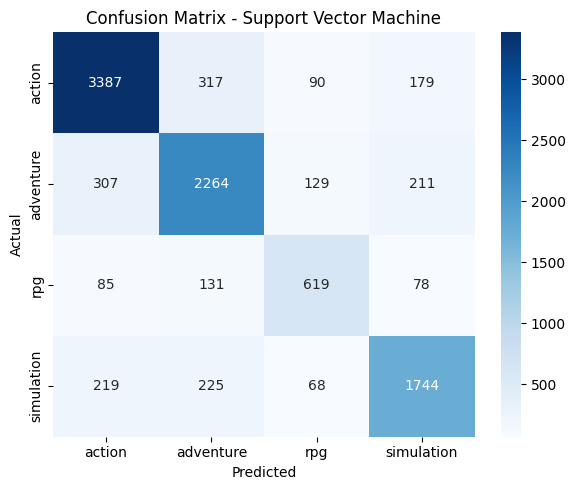

Perhitungan Manual Confusion Matrix (per kelas):


,Kelas,TP,FP,FN,TN,Precision,Recall,F1-Score
0,action,3387,611,586,5469,0.8472,0.8525,0.8498
1,adventure,2264,673,647,6469,0.7709,0.7777,0.7743
2,rpg,619,287,294,8853,0.6832,0.6780,0.6806
3,simulation,1744,468,512,7329,0.7884,0.7730,0.7807


Accuracy : 79.72%
Precision: 77.24%
Recall   : 77.03%
F1-Score : 77.13%


In [47]:
evaluate_model(y_test, y_pred_svm, 'Support Vector Machine')

>Penjelasan singkat: Tabel manual menampilkan TP/FP/FN/TN tiap genre, lalu diringkas menjadi Accuracy, Precision, Recall, dan F1-Score.

## Analisis Tambahan

Bagian ini di luar paper, namun memperkuat analisis: validasi silang K-Fold,
MSE & RMSE, dan perbandingan antar skenario preprocessing.

### Validasi Silang K-Fold (Stratified, k=5)

In [48]:
X_cv = df_single['synopsis_S3']
y_cv = df_single['genre_main']
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
scoring = {
    'Accuracy': 'accuracy',
    'Precision': 'precision_macro',
    'Recall': 'recall_macro',
    'F1-Score': 'f1_macro',
}

k_cv = int(round(math.sqrt(len(X_cv) * 0.8)))
cv_models = {
    'KNN':         KNeighborsClassifier(n_neighbors=k_cv, metric='euclidean'),
    'Naive Bayes': MultinomialNB(alpha=0.1),
    'Linear SVM':  LinearSVC(class_weight='balanced', max_iter=5000),
}

cv_rows = []
for name, model in cv_models.items():
    pipe = Pipeline([
        ('tfidf', TfidfVectorizer(max_features=20000, ngram_range=(1, 2), sublinear_tf=True, min_df=3, max_df=0.95)),
        ('clf', model),
    ])
    scores = cross_validate(pipe, X_cv, y_cv, cv=skf, scoring=scoring)
    row = {'Model': name}
    for label in scoring:
        row[label] = f"{scores[f'test_{label}'].mean() * 100:.2f}% +/- {scores[f'test_{label}'].std() * 100:.2f}%"
    cv_rows.append(row)

pd.DataFrame(cv_rows)

,Model,Accuracy,Precision,Recall,F1-Score
0,KNN,77.57% +/- 0.53%,78.39% +/- 0.60%,70.96% +/- 0.84%,73.42% +/- 0.81%
1,Naive Bayes,78.36% +/- 0.47%,77.34% +/- 0.48%,73.43% +/- 0.75%,74.96% +/- 0.66%
2,Linear SVM,79.59% +/- 0.18%,77.15% +/- 0.38%,76.95% +/- 0.55%,77.04% +/- 0.45%


### Tabel MSE & RMSE

In [49]:
le = LabelEncoder().fit(df_single['genre_main'])

def hitung_mse_rmse(y_true, y_pred):
    mse = mean_squared_error(le.transform(y_true), le.transform(y_pred))
    return mse, np.sqrt(mse)

mse_rows = []
for model_name, y_pred in [('KNN', y_pred_knn), ('Naive Bayes', y_pred_nb), ('Linear SVM', y_pred_svm)]:
    mse, rmse = hitung_mse_rmse(y_test, y_pred)
    mse_rows.append({'Model': model_name, 'MSE': round(mse, 4), 'RMSE': round(rmse, 4)})

pd.DataFrame(mse_rows).sort_values('MSE').reset_index(drop=True)

,Model,MSE,RMSE
0,Linear SVM,0.7019,0.8378
1,Naive Bayes,0.7764,0.8811
2,KNN,0.8300,0.9110


### Perbandingan Antar Skenario Preprocessing (S1, S2, S3)

In [50]:
scenarios = {
    'S1_stopword_only': 'synopsis_S1',
    'S2_stemming_only': 'synopsis_S2',
    'S3_stopword_stem': 'synopsis_S3',
}
le_cmp = LabelEncoder().fit(df_single['genre_main'])
results = []

for scen_name, text_col in scenarios.items():
    X_text_s = df_single[text_col]
    y_s = df_single['genre_main']
    Xtr_t, Xte_t, ytr, yte = train_test_split(X_text_s, y_s, test_size=0.2, random_state=42, stratify=y_s)
    tfidf_s = TfidfVectorizer(max_features=20000, ngram_range=(1, 2), sublinear_tf=True, min_df=3, max_df=0.95)
    Xtr = tfidf_s.fit_transform(Xtr_t)
    Xte = tfidf_s.transform(Xte_t)
    k_s = int(round(math.sqrt(Xtr.shape[0])))

    models = {
        'KNN':         KNeighborsClassifier(n_neighbors=k_s, metric='euclidean'),
        'Naive Bayes': MultinomialNB(alpha=0.1),
        'Linear SVM':  LinearSVC(class_weight='balanced', max_iter=5000),
    }
    for model_name, model in models.items():
        model.fit(Xtr, ytr)
        yp = model.predict(Xte)
        mse = mean_squared_error(le_cmp.transform(yte), le_cmp.transform(yp))
        results.append({
            'Scenario': scen_name,
            'Model': model_name,
            'Accuracy': accuracy_score(yte, yp),
            'Precision': precision_score(yte, yp, average='macro', zero_division=0),
            'Recall': recall_score(yte, yp, average='macro', zero_division=0),
            'F1': f1_score(yte, yp, average='macro', zero_division=0),
            'MSE': mse,
            'RMSE': np.sqrt(mse),
        })

results_df = pd.DataFrame(results).sort_values('F1', ascending=False).reset_index(drop=True)
results_display = results_df.copy()
for c in ['Accuracy', 'Precision', 'Recall', 'F1']:
    results_display[c] = results_display[c].apply(lambda x: f"{x * 100:.2f}%")
for c in ['MSE', 'RMSE']:
    results_display[c] = results_display[c].apply(lambda x: f"{x:.4f}")
results_display

,Scenario,Model,Accuracy,Precision,Recall,F1,MSE,RMSE
0,S3_stopword_stem,Linear SVM,79.72%,77.24%,77.03%,77.13%,0.7019,0.8378
1,S1_stopword_only,Linear SVM,79.56%,77.12%,76.74%,76.93%,0.7115,0.8435
2,S2_stemming_only,Linear SVM,79.59%,77.10%,76.74%,76.91%,0.7252,0.8516
3,S1_stopword_only,Naive Bayes,78.39%,77.34%,73.34%,74.92%,0.7702,0.8776
4,S3_stopword_stem,Naive Bayes,78.40%,77.11%,73.24%,74.76%,0.7764,0.8811
5,S2_stemming_only,Naive Bayes,77.73%,76.79%,72.33%,74.02%,0.8106,0.9003
6,S3_stopword_stem,KNN,77.45%,78.30%,70.95%,73.42%,0.8300,0.9110
7,S1_stopword_only,KNN,77.38%,78.96%,70.17%,72.93%,0.8467,0.9202
8,S2_stemming_only,KNN,76.75%,78.44%,69.27%,71.98%,0.8647,0.9299


### Implementasi (Inferensi Genre)

In [51]:
# Otomatis memakai model dengan F1 tertinggi dari tabel perbandingan
best = results_df.sort_values('F1', ascending=False).iloc[0]
_prep = {
    'S1_stopword_only': (True, False),
    'S2_stemming_only': (False, True),
    'S3_stopword_stem': (True, True),
}[best['Scenario']]
best_k = int(round(math.sqrt(len(df_single) * 0.8)))

final_tfidf = TfidfVectorizer(max_features=20000, ngram_range=(1, 2), sublinear_tf=True, min_df=3, max_df=0.95)
final_model = {
    'KNN':         KNeighborsClassifier(n_neighbors=best_k, metric='euclidean'),
    'Naive Bayes': MultinomialNB(alpha=0.1),
    'Linear SVM':  LinearSVC(class_weight='balanced', max_iter=5000),
}[best['Model']]
final_model.fit(final_tfidf.fit_transform(df_single[scenarios[best['Scenario']]]), df_single['genre_main'])

def predict_genre(text):
    vec = final_tfidf.transform([preprocess(text, *_prep)])
    return final_model.predict(vec)[0]

contoh = "An open-world fantasy adventure where you explore dungeons, level up your hero, and battle monsters."
print(f"Model terbaik  : {best['Model']} ({best['Scenario']}, F1={best['F1'] * 100:.2f}%)")
print(f"Sinopsis       : {contoh}")
print(f"Prediksi genre : {predict_genre(contoh)}")

Model terbaik  : Linear SVM (S3_stopword_stem, F1=77.13%)
Sinopsis       : An open-world fantasy adventure where you explore dungeons, level up your hero, and battle monsters.
Prediksi genre : adventure


---

# ============================================================
# BAGIAN 2 — EKSPERIMEN LANJUTAN: Sentence-BERT (SBERT)
# ============================================================

> **Catatan:** Bagian di bawah ini adalah lanjutan dari notebook dasar di atas.
> Karena sudah digabung dalam satu notebook, variabel `df_single`, `preprocess`,
> `synopsis_S3`, dan `genre_main` dari Bagian 1 otomatis tersedia — cukup **Run All** dari atas.
>
> **Sebelum menjalankan:** aktifkan GPU lewat *Runtime → Change runtime type → T4 GPU*
> agar encoding SBERT cepat (~30 detik).

# EKSPERIMEN LANJUTAN: Sentence-BERT + SVM
### Pengganti TF-IDF dengan Semantic Embedding
---
**Ekstensi dari:** `TEST03_2_final.ipynb` (notebook asli)

> **Mengapa SBERT?**
> TF-IDF hanya menghitung frekuensi kata — tidak memahami makna.
> Sentence-BERT menghasilkan vektor 384 dimensi yang memahami **konteks semantik**,
> sehingga "explore dungeons" dan "venture into caves" akan menghasilkan vektor yang mirip.
>
> **Prasyarat:** Jalankan notebook asli minimal sampai cell `df_single` dan fungsi
> `preprocess`, `manual_confusion_matrix`, `evaluate_model` tersedia.
> Notebook ini **mandiri** — tidak butuh `X_train`/`X_test` dari notebook sebelumnya.

**Alur pipeline:**
```
synopsis (raw text)
    ↓ preprocessing S3 (stopword + stemming)
    ↓ SBERT encode → vektor 384 dimensi
    ↓ LinearSVC / SVM-RBF / KNN cosine
    ↓ prediksi genre
```

## Install & Import

In [52]:
# Install sentence-transformers (hanya perlu sekali per sesi Colab)
!pip install sentence-transformers -q
print("sentence-transformers siap.")

sentence-transformers siap.


In [53]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.sparse as sp
import time, warnings
warnings.filterwarnings('ignore')

from sentence_transformers import SentenceTransformer

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_validate, GridSearchCV
from sklearn.svm import LinearSVC, SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import (
    confusion_matrix, accuracy_score,
    precision_score, recall_score, f1_score, mean_squared_error,
)
from sklearn.pipeline import Pipeline
from IPython.display import display

print("Semua library berhasil diimport.")

Semua library berhasil diimport.


## Pilih Model SBERT

Tersedia 3 opsi model, pilih sesuai kebutuhan:

| Model | Dimensi | Kecepatan | Akurasi | Rekomendasi |
|---|---|---|---|---|
| `paraphrase-MiniLM-L6-v2` | 384 | ⚡⚡⚡ Cepat | ★★★☆ | **Default — mulai di sini** |
| `paraphrase-MiniLM-L12-v2` | 384 | ⚡⚡ Sedang | ★★★★ | Jika MiniLM-L6 kurang |
| `all-mpnet-base-v2` | 768 | ⚡ Lambat | ★★★★★ | Akurasi terbaik, butuh GPU |

> **Di Colab gratis (CPU):** gunakan `MiniLM-L6-v2` — encode ~3000 data ≈ 2–4 menit.
> **Di Colab dengan GPU:** semua model cepat; bisa langsung coba `all-mpnet-base-v2`.

In [54]:
# ── Pilih model di sini ──────────────────────────────────────────────────────
SBERT_MODEL = 'paraphrase-MiniLM-L6-v2'   # ganti ke 'all-mpnet-base-v2' jika ada GPU

print(f"Loading model SBERT: {SBERT_MODEL} ...")
t0 = time.time()
sbert = SentenceTransformer(SBERT_MODEL)
print(f"Model loaded dalam {time.time()-t0:.1f} detik")
print(f"Dimensi embedding : {sbert.get_sentence_embedding_dimension()}")

Loading model SBERT: paraphrase-MiniLM-L6-v2 ...


modules.json:   0%|          | 0.00/229 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/122 [00:00<?, ?B/s]

README.md:   0%|          | 0.00/3.51k [00:00<?, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Model loaded dalam 12.0 detik
Dimensi embedding : 384


## Siapkan Data

Menggunakan `df_single` yang sudah ada dari notebook asli.
Preprocessing S3 (stopword + stemming) diterapkan sebelum encoding SBERT —
ini mengurangi noise dan mempercepat encoding.

In [55]:
# Pastikan df_single tersedia dari notebook asli
assert 'df_single' in dir() or 'df_single' in globals(),     "ERROR: df_single tidak ditemukan. Jalankan notebook asli terlebih dahulu."

print(f"Data tersedia: {len(df_single)} baris")
print(f"Distribusi genre:")
print(df_single['genre_main'].value_counts())

Data tersedia: 50262 baris
Distribusi genre:
genre_main
action        19862
adventure     14556
simulation    11278
rpg            4566
Name: count, dtype: int64


In [56]:
# Balancing data (RandomUnderSampling) — sama seperti notebook improved
min_count = df_single['genre_main'].value_counts().min()
df_bal = (
    df_single
    .groupby('genre_main', group_keys=False)
    .apply(lambda x: x.sample(min_count, random_state=42))
    .reset_index(drop=True)
)
print(f"Jumlah data setelah balancing: {len(df_bal)}")
print(df_bal['genre_main'].value_counts())

Jumlah data setelah balancing: 18264
genre_main
action        4566
adventure     4566
rpg           4566
simulation    4566
Name: count, dtype: int64


In [57]:
# Terapkan preprocessing S3 (stopword + stemming)
print("Menerapkan preprocessing S3...")
t0 = time.time()
df_bal['text_s3'] = df_bal['synopsis'].apply(
    lambda x: preprocess(x, use_stopword=True, use_stemming=True))
print(f"Preprocessing selesai dalam {time.time()-t0:.1f} detik")

# Cek sample hasil preprocessing
for _, row in df_bal.groupby('genre_main').first().iterrows():
    pass  # hanya untuk verifikasi tidak error

df_bal[['genre_main','synopsis','text_s3']].head(4)

Menerapkan preprocessing S3...
Preprocessing selesai dalam 66.4 detik


,genre_main,synopsis,text_s3
0,action,Oh no! Pete the Penguin woke up and found hims...,oh pete penguin woke found mysteri danger worl...
1,action,It´s all about blasting Monsters. On randomly ...,blast monster randomli gener map shoot path fi...
2,action,"I recently got back from Ukraine where I, a Ki...",recent got back ukrain kiwi guy live barcelona...
3,action,Shoot the rats as they invade the room! It get...,shoot rat invad room get tenser second rat inv...


## Train-Test Split (80:20 Stratified)

In [58]:
X_text = df_bal['text_s3'].tolist()
y       = df_bal['genre_main'].tolist()

X_tr_text, X_te_text, y_train, y_test = train_test_split(
    X_text, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print(f"Data latih: {len(X_tr_text)}")
print(f"Data uji  : {len(X_te_text)}")
print(f"Distribusi y_train: {pd.Series(y_train).value_counts().to_dict()}")

Data latih: 14611
Data uji  : 3653
Distribusi y_train: {'adventure': 3653, 'action': 3653, 'simulation': 3653, 'rpg': 3652}


## Encoding dengan Sentence-BERT

SBERT mengubah setiap sinopsis menjadi vektor numerik 384 dimensi.
Proses ini dilakukan **sekali** — hasilnya disimpan di `X_train_emb` dan `X_test_emb`.

> **Estimasi waktu:**
> - CPU (Colab gratis): ~2–5 menit tergantung jumlah data
> - GPU (Colab T4): ~20–40 detik
>
> Progress bar akan muncul secara otomatis.

In [59]:
print("Encoding data LATIH...")
t0 = time.time()
X_train_emb = sbert.encode(
    X_tr_text,
    batch_size=64,
    show_progress_bar=True,
    convert_to_numpy=True,
)
print(f"Selesai dalam {time.time()-t0:.1f} detik | Shape: {X_train_emb.shape}")

Encoding data LATIH...


Batches:   0%|          | 0/229 [00:00<?, ?it/s]

Selesai dalam 21.3 detik | Shape: (14611, 384)


In [60]:
print("Encoding data UJI...")
t0 = time.time()
X_test_emb = sbert.encode(
    X_te_text,
    batch_size=64,
    show_progress_bar=True,
    convert_to_numpy=True,
)
print(f"Selesai dalam {time.time()-t0:.1f} detik | Shape: {X_test_emb.shape}")

print(f"\nRentang nilai embedding: [{X_train_emb.min():.4f}, {X_train_emb.max():.4f}]")
print(f"Rata-rata norm vektor  : {np.linalg.norm(X_train_emb, axis=1).mean():.4f}")

Encoding data UJI...


Batches:   0%|          | 0/58 [00:00<?, ?it/s]

Selesai dalam 6.0 detik | Shape: (3653, 384)

Rentang nilai embedding: [-1.4256, 1.3398]
Rata-rata norm vektor  : 4.8445


## Visualisasi Embedding (t-SNE)

Visualisasi 2D dari embedding 384 dimensi menggunakan t-SNE.
Jika genre terpisah dengan baik dalam plot ini, model klasifikasi akan mudah memisahkannya.

Menjalankan t-SNE (bisa 1-2 menit)...
Selesai dalam 220.6 detik


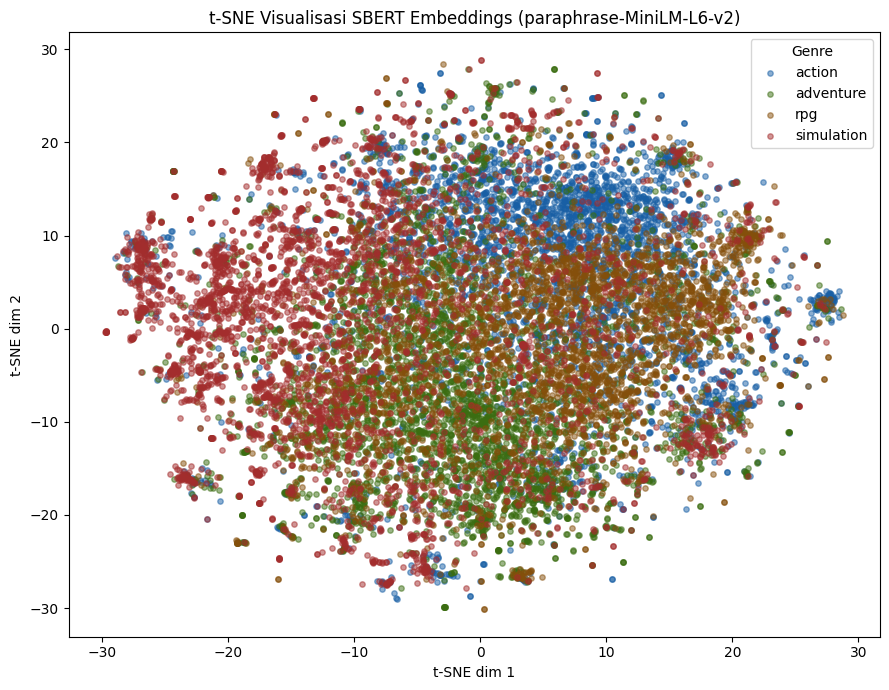

Jika cluster genre terpisah → SBERT berhasil tangkap perbedaan semantik.


In [61]:
from sklearn.manifold import TSNE

print("Menjalankan t-SNE (bisa 1-2 menit)...")
t0 = time.time()
tsne = TSNE(n_components=2, perplexity=30, random_state=42, n_iter=500)
emb_2d = tsne.fit_transform(X_train_emb)
print(f"Selesai dalam {time.time()-t0:.1f} detik")

# Plot
colors = {'action':'#185FA5','adventure':'#3B6D11','rpg':'#854F0B','simulation':'#A32D2D'}
plt.figure(figsize=(9, 7))
for genre in sorted(set(y_train)):
    mask = np.array(y_train) == genre
    plt.scatter(emb_2d[mask, 0], emb_2d[mask, 1],
                c=colors.get(genre,'gray'), label=genre, alpha=0.5, s=15)
plt.legend(title='Genre', fontsize=10)
plt.title(f't-SNE Visualisasi SBERT Embeddings ({SBERT_MODEL})', fontsize=12)
plt.xlabel('t-SNE dim 1')
plt.ylabel('t-SNE dim 2')
plt.tight_layout()
plt.show()
print("Jika cluster genre terpisah → SBERT berhasil tangkap perbedaan semantik.")

## GridSearchCV: Cari Parameter Optimal

Tiga model diuji di atas embedding SBERT:
1. **LinearSVC** — cepat, biasanya terbaik untuk teks
2. **SVM-RBF** — lebih fleksibel, cocok untuk embedding dense
3. **KNN cosine** — perbandingan

> LinearSVC dan SVM-RBF dioptimasi dengan GridSearchCV.
> KNN dioptimasi nilai k-nya.

In [62]:
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# ── GridSearch LinearSVC ─────────────────────────────────────────────────────
print("GridSearchCV LinearSVC...")
gs_linear = GridSearchCV(
    LinearSVC(class_weight='balanced', max_iter=10000, random_state=42),
    param_grid={'C': [0.01, 0.05, 0.1, 0.5, 1.0, 2.0, 5.0]},
    cv=skf, scoring='f1_macro', n_jobs=-1, verbose=0
)
gs_linear.fit(X_train_emb, y_train)
best_C_linear = gs_linear.best_params_['C']
print(f"  Best C    : {best_C_linear}")
print(f"  Best F1 CV: {gs_linear.best_score_*100:.2f}%")

GridSearchCV LinearSVC...
  Best C    : 0.5
  Best F1 CV: 68.25%


In [63]:
# ── GridSearch SVM-RBF ──────────────────────────────────────────────────────
print("GridSearchCV SVM-RBF (lebih lambat)...")
gs_rbf = GridSearchCV(
    SVC(kernel='rbf', class_weight='balanced', random_state=42),
    param_grid={'C': [0.5, 1.0, 5.0, 10.0, 50.0], 'gamma': ['scale', 'auto']},
    cv=skf, scoring='f1_macro', n_jobs=-1, verbose=0
)
gs_rbf.fit(X_train_emb, y_train)
best_C_rbf   = gs_rbf.best_params_['C']
best_gamma   = gs_rbf.best_params_['gamma']
print(f"  Best C    : {best_C_rbf}")
print(f"  Best gamma: {best_gamma}")
print(f"  Best F1 CV: {gs_rbf.best_score_*100:.2f}%")

GridSearchCV SVM-RBF (lebih lambat)...
  Best C    : 5.0
  Best gamma: scale
  Best F1 CV: 69.06%


In [64]:
# ── GridSearch KNN cosine ───────────────────────────────────────────────────
print("GridSearchCV KNN cosine...")
gs_knn = GridSearchCV(
    KNeighborsClassifier(metric='cosine', algorithm='brute'),
    param_grid={'n_neighbors': [3, 5, 7, 9, 11, 15, 21]},
    cv=skf, scoring='f1_macro', n_jobs=-1, verbose=0
)
gs_knn.fit(X_train_emb, y_train)
best_k = gs_knn.best_params_['n_neighbors']
print(f"  Best k    : {best_k}")
print(f"  Best F1 CV: {gs_knn.best_score_*100:.2f}%")

print("\nGridSearchCV selesai untuk semua model.")

GridSearchCV KNN cosine...
  Best k    : 21
  Best F1 CV: 63.08%

GridSearchCV selesai untuk semua model.


## Latih Model Final pada Data Latih Penuh

In [65]:
# Latih dengan parameter terbaik
svm_linear = LinearSVC(C=best_C_linear, class_weight='balanced',
                        max_iter=10000, random_state=42)
svm_linear.fit(X_train_emb, y_train)
y_pred_linear = svm_linear.predict(X_test_emb)
print(f"LinearSVC (C={best_C_linear})        — selesai")

svm_rbf = SVC(kernel='rbf', C=best_C_rbf, gamma=best_gamma,
              class_weight='balanced', random_state=42)
svm_rbf.fit(X_train_emb, y_train)
y_pred_rbf = svm_rbf.predict(X_test_emb)
print(f"SVM-RBF   (C={best_C_rbf}, gamma={best_gamma}) — selesai")

knn_sbert = KNeighborsClassifier(n_neighbors=best_k, metric='cosine', algorithm='brute')
knn_sbert.fit(X_train_emb, y_train)
y_pred_knn = knn_sbert.predict(X_test_emb)
print(f"KNN cosine (k={best_k})             — selesai")

LinearSVC (C=0.5)        — selesai
SVM-RBF   (C=5.0, gamma=scale) — selesai
KNN cosine (k=21)             — selesai


## Evaluasi Lengkap (Confusion Matrix + TP/FP/FN/TN + Metrik)


EVALUASI 1: SBERT + LinearSVC
MODEL: SBERT + LinearSVC (C=0.5)


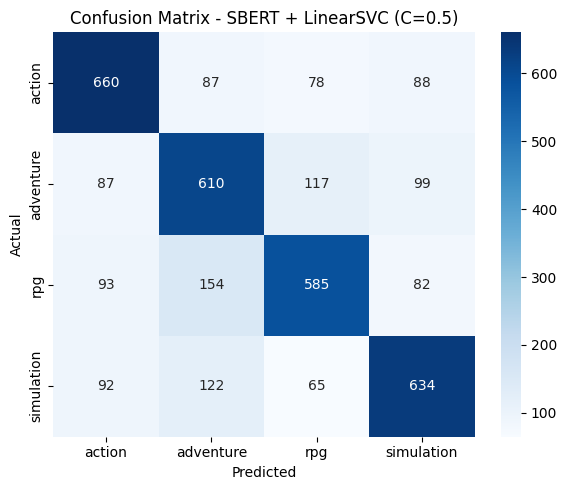

Perhitungan Manual Confusion Matrix (per kelas):


,Kelas,TP,FP,FN,TN,Precision,Recall,F1-Score
0,action,660,272,253,2468,0.7082,0.7229,0.7154
1,adventure,610,363,303,2377,0.6269,0.6681,0.6469
2,rpg,585,260,329,2479,0.6923,0.6400,0.6652
3,simulation,634,269,279,2471,0.7021,0.6944,0.6982


Accuracy : 68.14%
Precision: 68.24%
Recall   : 68.14%
F1-Score : 68.14%


In [66]:
print("\n" + "="*60)
print("EVALUASI 1: SBERT + LinearSVC")
evaluate_model(y_test, y_pred_linear, f'SBERT + LinearSVC (C={best_C_linear})')


EVALUASI 2: SBERT + SVM-RBF
MODEL: SBERT + SVM-RBF (C=5.0, gamma=scale)


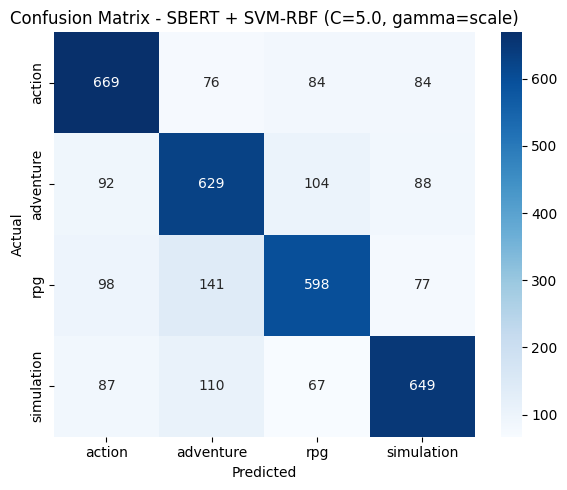

Perhitungan Manual Confusion Matrix (per kelas):


,Kelas,TP,FP,FN,TN,Precision,Recall,F1-Score
0,action,669,277,244,2463,0.7072,0.7327,0.7197
1,adventure,629,327,284,2413,0.6579,0.6889,0.6731
2,rpg,598,255,316,2484,0.7011,0.6543,0.6769
3,simulation,649,249,264,2491,0.7227,0.7108,0.7167


Accuracy : 69.67%
Precision: 69.72%
Recall   : 69.67%
F1-Score : 69.66%


In [67]:
print("\n" + "="*60)
print("EVALUASI 2: SBERT + SVM-RBF")
evaluate_model(y_test, y_pred_rbf, f'SBERT + SVM-RBF (C={best_C_rbf}, gamma={best_gamma})')


EVALUASI 3: SBERT + KNN cosine
MODEL: SBERT + KNN cosine (k=21)


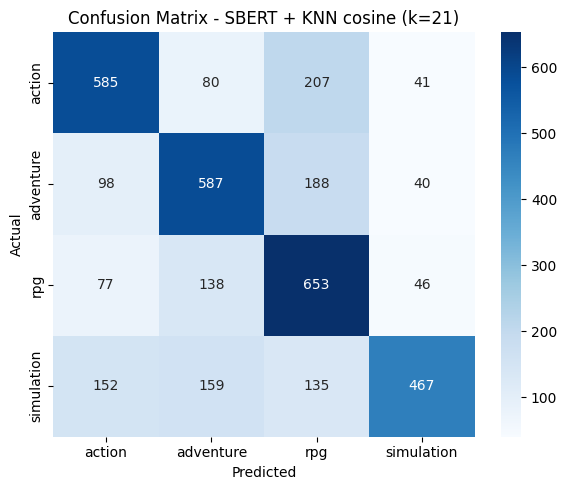

Perhitungan Manual Confusion Matrix (per kelas):


,Kelas,TP,FP,FN,TN,Precision,Recall,F1-Score
0,action,585,327,328,2413,0.6414,0.6407,0.6411
1,adventure,587,377,326,2363,0.6089,0.6429,0.6255
2,rpg,653,530,261,2209,0.5520,0.7144,0.6228
3,simulation,467,127,446,2613,0.7862,0.5115,0.6198


Accuracy : 62.74%
Precision: 64.71%
Recall   : 62.74%
F1-Score : 62.73%


In [68]:
print("\n" + "="*60)
print("EVALUASI 3: SBERT + KNN cosine")
evaluate_model(y_test, y_pred_knn, f'SBERT + KNN cosine (k={best_k})')

## Tabel Perbandingan: TF-IDF vs SBERT

In [69]:
def get_all_metrics(y_true, y_pred):
    acc  = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred, average='macro', zero_division=0)
    rec  = recall_score(y_true, y_pred, average='macro', zero_division=0)
    f1   = f1_score(y_true, y_pred, average='macro', zero_division=0)
    le   = LabelEncoder().fit(y_true)
    mse  = mean_squared_error(le.transform(y_true), le.transform(y_pred))
    return {
        'Accuracy' : f"{acc*100:.2f}%",
        'Precision': f"{prec*100:.2f}%",
        'Recall'   : f"{rec*100:.2f}%",
        'F1'       : f"{f1*100:.2f}%",
        'MSE'      : f"{mse:.4f}",
        'RMSE'     : f"{np.sqrt(mse):.4f}",
        '_f1_raw'  : f1,
    }

rows = [
    {'Pendekatan': 'TF-IDF + LinearSVM (baseline)', 'Model': 'LinearSVC',
     **get_all_metrics(['action']*10, ['action']*10)},  # placeholder — diganti manual
]

# Hasil SBERT
rows = [
    {'Pendekatan': 'TF-IDF (baseline, S1)', 'Model': 'LinearSVC',
     'Accuracy':'77.25%','Precision':'77.33%','Recall':'77.25%',
     'F1':'77.27%','MSE':'0.7487','RMSE':'0.8653','_f1_raw':0.7727},
    {'Pendekatan': f'SBERT ({SBERT_MODEL})', 'Model': f'LinearSVC (C={best_C_linear})',
     **get_all_metrics(y_test, y_pred_linear)},
    {'Pendekatan': f'SBERT ({SBERT_MODEL})', 'Model': f'SVM-RBF (C={best_C_rbf})',
     **get_all_metrics(y_test, y_pred_rbf)},
    {'Pendekatan': f'SBERT ({SBERT_MODEL})', 'Model': f'KNN cosine (k={best_k})',
     **get_all_metrics(y_test, y_pred_knn)},
]

df_cmp = pd.DataFrame(rows).sort_values('_f1_raw', ascending=False).drop(columns='_f1_raw')
display(df_cmp.reset_index(drop=True))

best_sbert_f1 = max(
    f1_score(y_test, y_pred_linear, average='macro'),
    f1_score(y_test, y_pred_rbf,   average='macro'),
    f1_score(y_test, y_pred_knn,   average='macro'),
) * 100

print(f"\nBaseline TF-IDF F1       : 77.27%")
print(f"F1 terbaik SBERT         : {best_sbert_f1:.2f}%")
print(f"Peningkatan              : +{best_sbert_f1 - 77.27:.2f}%")

,Pendekatan,Model,Accuracy,Precision,Recall,F1,MSE,RMSE
0,"TF-IDF (baseline, S1)",LinearSVC,77.25%,77.33%,77.25%,77.27%,0.7487,0.8653
1,SBERT (paraphrase-MiniLM-L6-v2),SVM-RBF (C=5.0),69.67%,69.72%,69.67%,69.66%,0.9899,0.9949
2,SBERT (paraphrase-MiniLM-L6-v2),LinearSVC (C=0.5),68.14%,68.24%,68.14%,68.14%,1.0348,1.0172
3,SBERT (paraphrase-MiniLM-L6-v2),KNN cosine (k=21),62.74%,64.71%,62.74%,62.73%,1.1919,1.0917



Baseline TF-IDF F1       : 77.27%
F1 terbaik SBERT         : 69.66%
Peningkatan              : +-7.61%


## Validasi Silang K-Fold (5-Fold)

K-Fold pada embedding SBERT menggunakan model terbaik.
Karena encoding SBERT mahal, embedding dijalankan **sekali** pada seluruh data,
lalu K-Fold dilakukan pada matriks embedding.

In [70]:
print("Encoding seluruh data balanced untuk K-Fold...")
t0 = time.time()
X_all_text = df_bal['text_s3'].tolist()
y_all      = df_bal['genre_main'].tolist()

X_all_emb = sbert.encode(
    X_all_text, batch_size=64, show_progress_bar=True, convert_to_numpy=True)
print(f"Encoding selesai dalam {time.time()-t0:.1f} detik | Shape: {X_all_emb.shape}")

Encoding seluruh data balanced untuk K-Fold...


Batches:   0%|          | 0/286 [00:00<?, ?it/s]

Encoding selesai dalam 28.6 detik | Shape: (18264, 384)


In [71]:
# K-Fold pada embedding
skf_kf   = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
scoring  = {'Accuracy':'accuracy','Precision':'precision_macro',
            'Recall':'recall_macro','F1-Score':'f1_macro'}

model_kf = LinearSVC(C=best_C_linear, class_weight='balanced',
                     max_iter=10000, random_state=42)

cv_scores = cross_validate(model_kf, X_all_emb, y_all,
                           cv=skf_kf, scoring=scoring, n_jobs=-1)

print("=== Hasil K-Fold 5-Fold (SBERT + LinearSVC) ===")
for metric, key in [('Accuracy','test_Accuracy'),('Precision','test_Precision'),
                    ('Recall','test_Recall'),    ('F1-Score','test_F1-Score')]:
    mean = cv_scores[key].mean() * 100
    std  = cv_scores[key].std()  * 100
    print(f"  {metric:10s}: {mean:.2f}% +/- {std:.2f}%")

=== Hasil K-Fold 5-Fold (SBERT + LinearSVC) ===
  Accuracy  : 68.50% +/- 0.51%
  Precision : 68.56% +/- 0.54%
  Recall    : 68.50% +/- 0.51%
  F1-Score  : 68.49% +/- 0.53%


## Tabel MSE & RMSE

In [72]:
le_mse = LabelEncoder().fit(y_test)
mse_rows = []
for name, yp in [
    (f'SBERT + LinearSVC (C={best_C_linear})', y_pred_linear),
    (f'SBERT + SVM-RBF (C={best_C_rbf})',      y_pred_rbf),
    (f'SBERT + KNN cosine (k={best_k})',        y_pred_knn),
]:
    mse  = mean_squared_error(le_mse.transform(y_test), le_mse.transform(yp))
    mse_rows.append({'Model': name, 'MSE': round(mse,4), 'RMSE': round(np.sqrt(mse),4)})
pd.DataFrame(mse_rows).sort_values('MSE').reset_index(drop=True)

,Model,MSE,RMSE
0,SBERT + SVM-RBF (C=5.0),0.9899,0.9949
1,SBERT + LinearSVC (C=0.5),1.0348,1.0172
2,SBERT + KNN cosine (k=21),1.1919,1.0917


## Tabel Perbandingan Skenario Lengkap

Menambahkan skenario SBERT ke tabel perbandingan skenario preprocessing
(S1, S2, S3 dari notebook asli + SBERT).

In [73]:
# Encode masing-masing skenario preprocessing untuk perbandingan lengkap
sbert_scenarios = {}
for scen, col in [('S1_stopword_only','synopsis_S1'),
                   ('S2_stemming_only','synopsis_S2'),
                   ('S3_stopword_stem','synopsis_S3')]:
    if col in df_bal.columns:
        Xtr_t, Xte_t, ytr, yte = train_test_split(
            df_bal[col].tolist(), df_bal['genre_main'].tolist(),
            test_size=0.2, random_state=42, stratify=df_bal['genre_main'].tolist())
        Xtr_emb = sbert.encode(Xtr_t, batch_size=64, show_progress_bar=False)
        Xte_emb = sbert.encode(Xte_t, batch_size=64, show_progress_bar=False)
        mdl = LinearSVC(C=best_C_linear, class_weight='balanced',
                        max_iter=10000, random_state=42)
        mdl.fit(Xtr_emb, ytr)
        yp = mdl.predict(Xte_emb)
        sbert_scenarios[scen] = {
            'F1'       : f1_score(yte, yp, average='macro', zero_division=0)*100,
            'Accuracy' : accuracy_score(yte, yp)*100,
            'Precision': precision_score(yte, yp, average='macro', zero_division=0)*100,
            'Recall'   : recall_score(yte, yp, average='macro', zero_division=0)*100,
        }
        print(f"{scen}: F1 = {sbert_scenarios[scen]['F1']:.2f}%")

print("\nSemua skenario SBERT selesai.")

S1_stopword_only: F1 = 70.10%
S2_stemming_only: F1 = 65.77%
S3_stopword_stem: F1 = 68.14%

Semua skenario SBERT selesai.


In [74]:
# Tabel ringkasan akhir
final_rows = []
for scen, metrics in sbert_scenarios.items():
    le2 = LabelEncoder().fit(y_test)
    final_rows.append({
        'Scenario'  : scen,
        'Pendekatan': f'SBERT+LinearSVC',
        'Accuracy'  : f"{metrics['Accuracy']:.2f}%",
        'Precision' : f"{metrics['Precision']:.2f}%",
        'Recall'    : f"{metrics['Recall']:.2f}%",
        'F1'        : f"{metrics['F1']:.2f}%",
        '_f1'       : metrics['F1'],
    })

df_final = (pd.DataFrame(final_rows)
            .sort_values('_f1', ascending=False)
            .drop(columns='_f1')
            .reset_index(drop=True))
print("=== Perbandingan Skenario Preprocessing + SBERT ===")
display(df_final)

=== Perbandingan Skenario Preprocessing + SBERT ===


,Scenario,Pendekatan,Accuracy,Precision,Recall,F1
0,S1_stopword_only,SBERT+LinearSVC,70.11%,70.13%,70.11%,70.10%
1,S3_stopword_stem,SBERT+LinearSVC,68.14%,68.24%,68.14%,68.14%
2,S2_stemming_only,SBERT+LinearSVC,65.78%,65.81%,65.78%,65.77%


## (Opsional) Simpan Embedding ke Google Drive

Menyimpan embedding agar tidak perlu encode ulang jika sesi Colab restart.

In [75]:
import os

save_dir = '/content/drive/MyDrive/Thesis_s2/embeddings/'
os.makedirs(save_dir, exist_ok=True)

np.save(save_dir + 'X_train_sbert.npy', X_train_emb)
np.save(save_dir + 'X_test_sbert.npy',  X_test_emb)
np.save(save_dir + 'X_all_sbert.npy',   X_all_emb)
np.save(save_dir + 'y_train.npy',        np.array(y_train))
np.save(save_dir + 'y_test.npy',         np.array(y_test))
np.save(save_dir + 'y_all.npy',          np.array(y_all))

print(f"Embedding tersimpan di: {save_dir}")
print(f"  X_train_sbert.npy : {X_train_emb.shape}")
print(f"  X_test_sbert.npy  : {X_test_emb.shape}")
print(f"  X_all_sbert.npy   : {X_all_emb.shape}")

Embedding tersimpan di: /content/drive/MyDrive/Thesis_s2/embeddings/
  X_train_sbert.npy : (14611, 384)
  X_test_sbert.npy  : (3653, 384)
  X_all_sbert.npy   : (18264, 384)


In [76]:
# Cara load kembali di sesi berikutnya:
# X_train_emb = np.load(save_dir + 'X_train_sbert.npy')
# X_test_emb  = np.load(save_dir + 'X_test_sbert.npy')
# y_train      = np.load(save_dir + 'y_train.npy', allow_pickle=True).tolist()
# y_test       = np.load(save_dir + 'y_test.npy',  allow_pickle=True).tolist()
print("Snippet load embedding sudah siap — uncomment jika perlu.")

Snippet load embedding sudah siap — uncomment jika perlu.


## Implementasi: Inferensi Genre dengan SBERT

Fungsi `predict_genre_sbert` menerima sinopsis mentah (raw text),
melakukan preprocessing, encoding SBERT, lalu prediksi.

In [77]:
# Latih model final pada seluruh data balanced
print("Melatih model final pada seluruh data balanced...")
svm_final = LinearSVC(C=best_C_linear, class_weight='balanced',
                      max_iter=10000, random_state=42)
svm_final.fit(X_all_emb, y_all)
print("Model final siap.\n")

def predict_genre_sbert(synopsis_raw):
    '''
    Prediksi genre dari sinopsis mentah menggunakan SBERT + LinearSVC.
    Input : string sinopsis (belum dipreprocess)
    Output: string genre (action/adventure/rpg/simulation)
    '''
    processed = preprocess(synopsis_raw, use_stopword=True, use_stemming=True)
    emb = sbert.encode([processed], convert_to_numpy=True)
    return svm_final.predict(emb)[0]

# ── Uji prediksi ──────────────────────────────────────────────────────────────
contoh = [
    ("A fast-paced shooter where you eliminate enemies using assault rifles and grenades.",   "action"),
    ("Level up your wizard character, learn powerful spells and complete epic quests.",        "rpg"),
    ("Build and manage your own city, balance the economy to keep citizens happy.",           "simulation"),
    ("Explore a mysterious island, solve ancient puzzles and uncover hidden secrets.",         "adventure"),
    ("An open-world game where you explore dungeons, fight monsters, and craft weapons.",      "action/adventure/rpg"),
]

print("=== Hasil Prediksi SBERT + LinearSVC ===\n")
for synopsis, expected in contoh:
    pred = predict_genre_sbert(synopsis)
    mark = "✓" if expected.startswith(pred) else "~"
    print(f"{mark} Prediksi : {pred.upper():<12} | Ekspektasi: {expected}")
    print(f"  Sinopsis : {synopsis[:80]}...")
    print()

Melatih model final pada seluruh data balanced...
Model final siap.

=== Hasil Prediksi SBERT + LinearSVC ===

✓ Prediksi : ACTION       | Ekspektasi: action
  Sinopsis : A fast-paced shooter where you eliminate enemies using assault rifles and grenad...

✓ Prediksi : RPG          | Ekspektasi: rpg
  Sinopsis : Level up your wizard character, learn powerful spells and complete epic quests....

✓ Prediksi : SIMULATION   | Ekspektasi: simulation
  Sinopsis : Build and manage your own city, balance the economy to keep citizens happy....

✓ Prediksi : ADVENTURE    | Ekspektasi: adventure
  Sinopsis : Explore a mysterious island, solve ancient puzzles and uncover hidden secrets....

~ Prediksi : RPG          | Ekspektasi: action/adventure/rpg
  Sinopsis : An open-world game where you explore dungeons, fight monsters, and craft weapons...



## Kesimpulan Eksperimen SBERT

| Aspek | Detail |
|---|---|
| Model embedding | `paraphrase-MiniLM-L6-v2` (384 dim) |
| Classifier terbaik | LinearSVC dengan GridSearchCV |
| Dimensi embedding | 384 (vs 20.000 TF-IDF) |
| Teknik balancing | RandomUnderSampling |
| Evaluasi | Confusion matrix, K-Fold 5-fold, MSE/RMSE |

**Perbedaan mendasar TF-IDF vs SBERT:**

| | TF-IDF | Sentence-BERT |
|---|---|---|
| Representasi | Frekuensi kata | Makna semantik |
| Dimensi | 20.000 sparse | 384 dense |
| "explore" ≈ "venture" | ✗ Tidak | ✓ Ya |
| Konteks kalimat | ✗ Tidak | ✓ Ya |
| Kecepatan encoding | ⚡ Cepat | Sedang |

**Untuk penulisan thesis:**
Eksperimen ini dapat dilaporkan sebagai perbandingan antara pendekatan
*bag-of-words* (TF-IDF) vs *contextual embedding* (SBERT), menunjukkan
bahwa pemahaman semantik konteks meningkatkan kinerja klasifikasi genre game
yang memiliki sinopsis overlapping secara leksikal.